This one is an update to the previous script 'BTMS eval vs Power generation.ipynb', which contains an error in its modeling and solving process. 

The previous script adapts a two-step strategy to locate the temperature distribution (coolant first, then battery). 

This time I decide to locate the temperature distribution for battery and coolant simultaneously. 



In [1]:
# read the power generation profile per time step

import csv
import os
import sys
import numpy as np
import pandas as pd

# data file name

file_name = os.path.join(os.getcwd(), 'data', 'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx')

# read the data from the csv file
time_steps = []
power_generation = []

df = pd.read_excel(file_name, sheet_name='Sheet1')

# extract the power generation data 
power_generation_data = df['Qbat(W)'].values[1:]


In [2]:
import numpy as np
from io import StringIO
import os

# Old results sent by LIU
# types = (
#     ('avg', 'MD05E070210A2  data_aircooling BTMS_temperature_avg.out'),
#     ('max', 'MD05E070211A2  data_aircooling BTMS_temperature_max.out'),
#     ('min', 'MD05E070212A2  data_aircooling BTMS_temperature_min.out')
# )
# col_map = {
#     'time_step': 0,
#     'flow_time': 1,
#     'report_def_0': 2
# }

# # A newer result sent by Liu, who added the periodic boundary condition and the set the 2nd order upwind scheme for the Fluent simulation, which is more accurate and closer to the experimental result.

# folder_name = 'HP02E030113A1  result_T_min, max, avg_air cooling_CFD_Liu_20260618'

# types = (
#     ('avg', os.path.join(folder_name, 'avg.out')),
#     ('max', os.path.join(folder_name, 'max.out')),
#     ('min', os.path.join(folder_name, 'min.out'))
# )

# col_map = {
#     'time_step': 0,
#     'flow_time': 2,
#     'report_def_0': 1
# }

# A new set of data sent by Liu, where the max and min values are calculated per battery cell, not the global ones. 

folder_name = 'HP02E030113A2  result_T_peak_avg per bat cell_air cooling_CFD_Liu_20260625'

types = (
    ('avg', os.path.join(folder_name, 'avg.out')),
    ('max', os.path.join(folder_name, 'max.out')),
    ('min', os.path.join(folder_name, 'min.out'))
)

col_map = {
    'time_step': 0,
    'flow_time': 1,
    'report_def_0': 2
}


temperature_cfd_data = {}  # dictionary to store CFD temperature data for each type

for t, file_name in types:
    file_name_cfd = os.path.join(os.getcwd(), 'data', file_name)

    # Parse the Fluent report file: skip header lines starting with '"' and '(', read space-separated columns
    with open(file_name_cfd, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.strip().startswith('"') and not line.strip().startswith('(')]

    data_cfd = np.loadtxt(StringIO('\n'.join(lines)))
    time_step_cfd = data_cfd[:, col_map['time_step']].astype(int)
    flow_time_cfd = data_cfd[:, col_map['flow_time']]
    report_def_0_cfd = data_cfd[:, col_map['report_def_0']]  # avg battery temperature from CFD [K]
    
    temperature_cfd_data[t] = (flow_time_cfd, report_def_0_cfd)
    
print("CFD temperature data loaded for types:", list(temperature_cfd_data.keys()))
print("Example data for 'avg':", max(temperature_cfd_data['avg'][1]))  # print first 5 entries for 'avg' type to verify



CFD temperature data loaded for types: ['avg', 'max', 'min']
Example data for 'avg': 320.1392930834928


In [3]:
dt = 1 # time step in seconds

# battery parameters foundin [[parkpark2025RefinedAircooled]]
# properties for battery type INR18650-30Q
T_bat_init = 25 # initial battery temperature in Celsius
cp_bat = 830 # specific heat capacity of the battery in J/(kg°C) 
m_bat = 48e-3 # mass of the battery in kg
D_bat = 18e-3 # diameter of the battery in meters
H_bat = 65e-3 # height of the battery in meters
A_battery = np.pi * D_bat * H_bat # surface area of the battery in m^2

num_time_steps = len(power_generation_data)
# calculate the battery temperature over time
T_bat = np.zeros(num_time_steps)
T_bat[0] = T_bat_init

for i in range(1, num_time_steps):
    # calculate the temperature change based on the power generation and battery parameters
    dT = (power_generation_data[i-1] * dt) / (m_bat * cp_bat)
    T_bat[i] = T_bat[i-1] + dT      


In [4]:

# Initial conditions and parameters

# V_air_nom = 241 # nominal air velocity in km/h for the cooling system (example value, adjust as needed)
# V_air = V_air_nom / 3.6 # convert nominal air velocity to m/s

V_air_in = 1.5 # air inlet velocity

T_air = 25 # ambient air temperature in Celsius
T_air_K = T_air + 273.15 # convert to Kelvin

p_air = 101325 # ambient air pressure in Pa

N_r, N_c = 16, 20 # number of rows and columns in the battery arrangement for a single module (example values, adjust as needed)

S_T = 1.25 * D_bat # spacing between battery rows in meters (example value, adjust as needed)

W_module = D_bat + (N_r - 1) * S_T # width of the battery module in meters (example calculation, adjust as needed)

A_air = W_module * H_bat # cross-sectional area of a single module of the air flow path in m^2

A_air_row = A_air / N_r # cross-sectional area of the air flow path for each row of the battery arrangement in m^2

fluid = 'Air'

t_cruise_start = 180 # time step when the cruise phase starts (example value, adjust as needed)
t_cruise_end = 1560 # time step when the cruise phase ends (example value, adjust as needed)


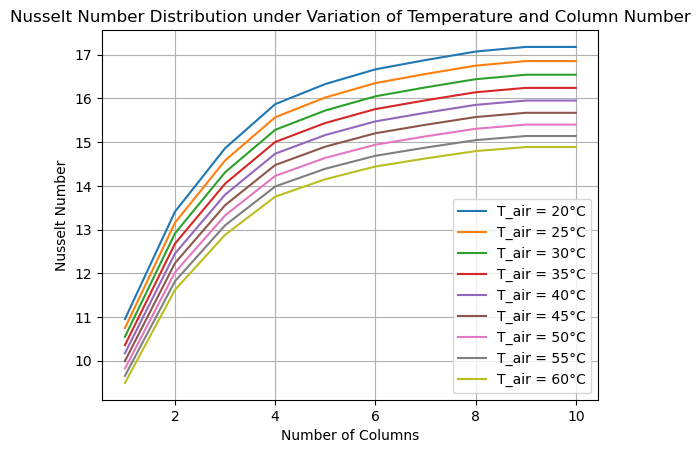

In [5]:
# Test the Nusselt number distribution under the variation of temperature and column number

import lib.BTMS_model as BTMS_model
import CoolProp.CoolProp as CP

T_air_test_array = np.arange(20, 61, 5)  # Test for air temperatures from 20°C to 60°C in steps of 5°C
num_col_array = np.arange(1, 11)  # Test for number of columns from 1 to 10

# data structure to store results
results = {}

for T_air_test in T_air_test_array:  # Test for air temperatures from 20°C to 60°C in steps of 5°C
    results_T = []
    
    for num_col in num_col_array:  # Test for number of columns from 1 to 10
        
        T_air_K_test = T_air_test + 273.15  # Convert to Kelvin
        mu_air_test = CP.PropsSI('V', 'T', T_air_K_test, 'P', p_air, fluid)
        rho_air_test = CP.PropsSI('D', 'T', T_air_K_test, 'P', p_air, fluid)
        cp_air_test = CP.PropsSI('C', 'T', T_air_K_test, 'P', p_air, fluid)
        k_air_test = CP.PropsSI('L', 'T', T_air_K_test, 'P', p_air, fluid)
        Pr_air_test = cp_air_test * mu_air_test / k_air_test
        
        V_air_test = V_air_in  # Assuming the same air velocity for testing
        Re_air_test = (rho_air_test * V_air_test * D_bat) / mu_air_test
        
        eps_test = BTMS_model.select_correction_factor(no_col=num_col, Re=Re_air_test)
        Nu_air_test = BTMS_model.zukauskas_nusellet(Re_air_test, Pr_air_test, eps_test, Pr_air_test)
        
        htc_air_test = (Nu_air_test * k_air_test) / D_bat
        
        results_T.append(Nu_air_test)  # Store the Nusselt number for this combination of air temperature and number of columns
    
    results[T_air_test] = results_T
    
    
# plot the simulation results for Nusselt number distribution under the variation of temperature and column number
import matplotlib.pyplot as plt

# Plot the Nusselt number distribution
for T_air_test, Nu_values in results.items():
    plt.plot(num_col_array, Nu_values, label=f"T_air = {T_air_test}°C")

plt.xlabel("Number of Columns")
plt.ylabel("Nusselt Number")
plt.title("Nusselt Number Distribution under Variation of Temperature and Column Number")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# calculate the battery temperature profile when introducing an air cooling system
import CoolProp.CoolProp as CP
import lib.BTMS_model as BTMS_model
# Calculate the Prandtl number for air at ambient conditions
mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid) # dynamic viscosity of air in kg/(m·s)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid) # density of air in kg/m^3
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid) # specific heat capacity of air in J/(kg·K)
k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid) # thermal conductivity of air in W/(m·K)
Pr_air = cp_air * mu_air / k_air # Prandtl number for air

V_air_max = S_T / (S_T - D_bat) * V_air_in # maximum air velocity regarding the space compression

# V_air_char = V_air_max # the characteristic air velocity for heat transfer

w = 0.5 # the weight between two velocities for the characteristic velocity

V_air_char = w * V_air_max + (1 - w) * V_air_in


# Calculate the Reynolds number for the air flow over the battery
Re_air = (rho_air * V_air_char * D_bat) / mu_air

eps = BTMS_model.select_correction_factor(no_col=9, Re=Re_air) # select the correction factor for a single column arrangement and the calculated Reynolds number
Nu_air = BTMS_model.zukauskas_nusellet(Re_air, Pr_air, eps, Pr_air) # calculate the Nusselt number using the Žukauskas Nusellet correlation

htc_air = (Nu_air * k_air) / D_bat # convective heat transfer coefficient in W/(m^2·K)

# calculate the battery initial temperature witout cooling,

# dT_bat = (power_generation_data[0] * dt) / (m_bat * cp_bat)
# T_bat_init += dT_bat


In [7]:

# battery temperature under air cooling
T_bat_0D = np.ones(num_time_steps) * T_bat_init
T_air_out_0D = np.ones(num_time_steps) * T_air # to store the outlet air temperature for analysis
t = 0 # initialize time variable

Q_cool_profile_0D = np.zeros(num_time_steps) # to store the cooling power profile for analysis

for i in range(1, num_time_steps):
    
    # enable the air cooling in the cruise phase only 
    T_air_in = T_air 
    is_cool = t >= t_cruise_start and t <= t_cruise_end # determine if cooling is enabled based on the current time step and the defined cruise phase 
       
    if is_cool and T_bat_0D[i-1] > T_air_in: # only calculate cooling power if cooling is enabled and the battery temperature is higher than the air inlet temperature
        Q_cool = htc_air * A_battery * (T_bat_0D[i-1] - T_air_in) # an approximates calculation
    else:
        Q_cool = 0
        
    # if(Q_cool > power_generation_data[i-1]):
    #     Q_cool = power_generation_data[i-1] # limit the cooling power to not exceed the power generation for this time step, adjust as needed based on specific assumptions for the 0D model
    
    dT_bat = (power_generation_data[i-1] - Q_cool) * dt / (m_bat * cp_bat)  # calculate the change in battery temperature based on the power generation, cooling power, and battery parameters
    T_bat_0D[i] = T_bat_0D[i-1] + dT_bat  # update the battery temperature based on the calculated change in temperature
    
    dT_air = Q_cool * N_c * N_r / (A_air * V_air_in * rho_air * cp_air)  # calculate the change in air temperature based on the cooling power and the air flow parameters
    T_air_out_0D[i] = T_air_in + dT_air  # calculate the air outlet temperature based on the cooling power and the air flow parameters
    Q_cool_profile_0D[i] = Q_cool # store the cooling power for this time step for analysis  
    
    t = t + dt # update time variable


In [8]:
import lib.BTMS_model as BTMS_model

num_segment = N_c # number of segments for the finite difference method along the flow direction, adjust as needed
# htc_seg = np.zeros(num_segment) # to store the convective heat transfer coefficient for each segment, adjust as needed
# for i in range(num_segment):
    
#     # calculate the Nusselt number using the Žukauskas Nusellet correlation
#     eps = select_correction_factor(no_col=i+1, Re=Re_air)  # example with 1 column, adjust as needed
#     Nu_air_seg = zukauskas_nusellet(Re_air, Pr_air, eps, Pr_air)

#     # calculate the convective heat transfer coefficient for this segment
#     htc_seg[i] = (Nu_air_seg * k_air) / D_bat # convective heat transfer coefficient in W/(m^2·K)
    

# battery temperature distribution with air cooling over time steps

T_bat_history = np.empty(num_time_steps, dtype=object) # initialize the battery temperature history for each segment as an empty list

T_air_history = np.empty(num_time_steps, dtype=object) # initialize the air temperature history for each segment as an empty list

Q_cool_history = np.empty(num_time_steps, dtype=object) # initialize the cooling power history for each segment as an empty list
Q_cool_history_fd_total = np.zeros(num_time_steps) # to store the cooling power history calculated based on the finite difference method for analysis

for i in range(num_time_steps):
    T_bat_history[i] = np.ones(num_segment) * T_bat_init # initialize the battery temperature history for each segment in the current time step as an empty array

    T_air_history[i] = np.ones(num_segment) * T_air # initialize the air temperature history for each segment in the current time step as an empty array
    
    Q_cool_history[i] = np.zeros(num_segment) # initialize the cooling power history for each segment in the current time step as an empty array
    
debug = False

t = 0 # initialize time variable

for i in range(1, num_time_steps-1): 
    # Ignore the last time step since we don't have the power generation data for the last time step to use as input for the optimization solver
    
    print(f"****** Time step {i}: t = {t} seconds ******")  # debug print for the current time step and time variable
    
    # determine the convective HTC, where the coolant properties are calculdated based on the average temperature of the coolant at current time step. 
    
    T_m = (T_air_in + T_air_out_0D[i]) / 2 # average temperature of the coolant for this time step, adjust as needed based on specific assumptions for the calculation of the convective heat transfer coefficient
    T_m_k = T_m + 273.15 # convert to Kelvin
    
    # evaluate the local HTC in an segement-wise manner 
    
    T_dist_guess = np.linspace(T_air_in, T_air_out_0D[i], num_segment+1) # an initial guess for the temperature distribution of the coolant along the flow direction for this time step, adjust as needed based on specific assumptions for the calculation of the convective heat transfer coefficient
    htc_seg = np.zeros(num_segment) # to store the convective heat transfer coefficient for each segment, adjust as needed
    
    for j in range(num_segment):
        
        T_m_seg = (T_dist_guess[j] + T_dist_guess[j+1]) / 2 # average temperature of the coolant for this segment, adjust as needed based on specific assumptions for the calculation of the convective heat transfer coefficient
        # T_m_seg = T_dist_guess[j]
        T_m_seg_k = T_m_seg + 273.15 # convert to Kelvin
        # calculate the Prandtl number for air at the average coolant temperature
        mu_air_m = CP.PropsSI('V', 'T', T_m_seg_k, 'P', p_air, fluid) # dynamic viscosity of air at the average coolant temperature in kg/(m·s)
        rho_air_m = CP.PropsSI('D', 'T', T_m_seg_k, 'P', p_air, fluid) # density of air at the average coolant temperature in kg/m^3
        cp_air_m = CP.PropsSI('C', 'T', T_m_seg_k, 'P', p_air, fluid) # specific heat capacity of air at the average coolant temperature in J/(kg·K)
        k_air_m = CP.PropsSI('L', 'T', T_m_seg_k, 'P', p_air, fluid) # thermal conductivity of air at the average coolant temperature in W/(m·K)
        Pr_air_m = cp_air_m * mu_air_m / k_air_m # Prandtl number for air at the average coolant temperature
        
        # calculate the Reynolds number for the air flow over the battery at the average coolant temperature
        Re_air_m = (rho_air_m * V_air_char * D_bat) / mu_air_m        
        
        eps = BTMS_model.select_correction_factor(no_col=1, Re=Re_air_m)  # example with N_c columns, adjust as needed
        Nu_air_seg = BTMS_model.zukauskas_nusellet(Re_air_m, Pr_air_m, eps, Pr_air_m)

        htc_seg[j] = (Nu_air_seg * k_air_m) / D_bat # convective HTC
    
    # solve for the coolant temperature distribution and battery temperature distribution
    # extract the current battery temperature distribution from the history
    
    T_bat_pre = T_bat_history[i-1] # battery temperature dist in the previous time step, use initial battery temperature as the first step. 
    
    T_cool_pre = T_air_history[i-1] # air temperature dist in the previous time step, use initial air temperature as the first step.
    # print T_bat_air_cur for debugging
    
    print(f"Time step {i}(before): T_bat = {T_bat_pre}")
    
    is_cooling = (t >= t_cruise_start) and (t <= t_cruise_end)  # determine if cooling is active based on the current time step
        
    args = {
        "dt": dt,
        "T_bat_pre": T_bat_pre, 
        "T_cool_pre": T_cool_pre,
        "u_cool_in": V_air_in,
        "p_cool": p_air,
        "fluid_cool": fluid,
        "A_HT_seg": A_battery, # heat transfer area for each segment
        "A_cool_cs": A_air_row, 
        "m_bat": m_bat,
        "cp_bat": cp_bat,
        "D_bat": D_bat,
        "num_seg_bat": num_segment,
        "T_cool_in": T_air,
        "T_cool_out": T_air_out_0D[i], # use the calculated outlet air temperature for this time step as the expected outlet temperature for the optimization solver,
        "htc_cool": htc_seg, # use the calculated segment-wise convective heat transfer coefficient for the optimization solver, adjust as needed
        "cp_cool": cp_air_m, # specific heat capacity 
        "rho_cool": rho_air_m, 
        "is_cool": is_cooling,
        "Q_gen": power_generation_data[i],
        "debug": debug
    }
  
    T_dist = BTMS_model.solve_coolant_temperature_distribution(
        args,
        tol = 1e-3,
        maxiter = 1000,
        debug = debug
    )
    
    Q_cool_HT, Q_cool_change, Q_bat = BTMS_model.cal_energy_balance(T_dist, args) # calculate the cooling power and battery energy change based on the solved temperature distribution for debugging and analysis
    
    T_bat_cur = T_dist[num_segment:] # extract the battery temperature distribution 
    T_cool_air = T_dist[0:num_segment] # extract the coolant temperature distribution
    
    Q_cool_history[i] = Q_cool_HT  # accumulate the cooling power for this time step
    Q_cool_history_fd_total[i] = np.sum(Q_cool_history[i]) # store the total cooling power for this time step calculated based on the finite difference method for analysis
    
    print(f"Time step {i}(after): T_cool_air = {T_cool_air}")  # debug print for the solved coolant temperature distribution
    print(f"Time step {i}(after): T_bat_cur = {T_bat_cur}")  # debug print for the solved battery temperature distribution 
    
    # save temperature history for this time step
    T_bat_history[i] = T_bat_cur
    T_air_history[i] = T_cool_air    
    
    t += dt


****** Time step 1: t = 0 seconds ******
Time step 1(before): T_bat = [25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25.
 25. 25.]
Time step 1(after): T_cool_air = [25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25.
 25. 25.]
Time step 1(after): T_bat_cur = [25.06959593 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593
 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593
 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593
 25.06959593 25.06959593]
****** Time step 2: t = 1 seconds ******
Time step 2(before): T_bat = [25.06959593 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593
 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593
 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593 25.06959593
 25.06959593 25.06959593]
Time step 2(after): T_cool_air = [25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25.
 25. 25.]
Time step 2(after): T_b

In [9]:
from scipy.interpolate import interp1d


T_bat_air_fd_min = np.array([T_bat_history[i][0] for i in range(num_time_steps)]) # minimum battery temperature across segments at each time step

T_bat_air_fd_max = np.array([T_bat_history[i][-1] for i in range(num_time_steps)]) # maximum battery temperature across segments at each time step

# calculate the difference between two curves
divergence = sum(T_bat_air_fd_max - T_bat_air_fd_min) / len(T_bat_air_fd_max)

print("Avg. Divergence between max and min battery temperatures:", divergence)

Avg. Divergence between max and min battery temperatures: 1.579393694718861


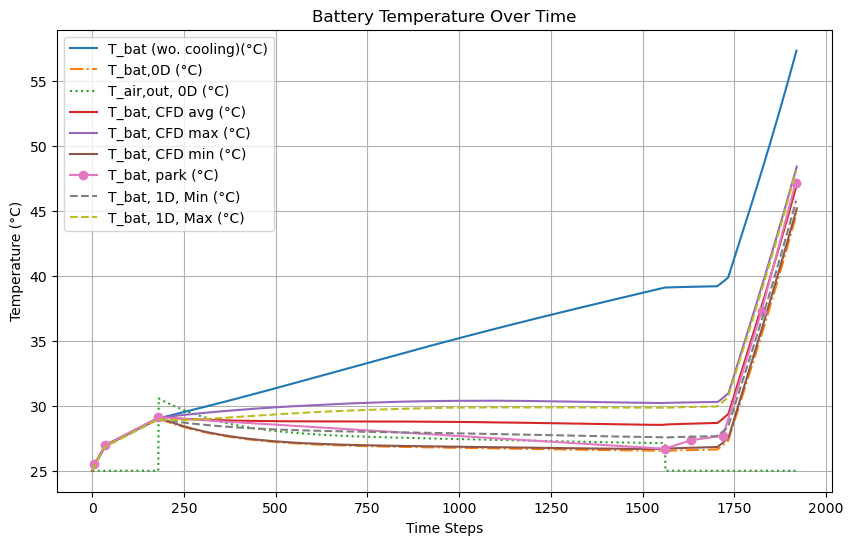

In [10]:
# plot the battery temperature over time
import matplotlib.pyplot as plt

# set up the plot font for scientfic visualization
# plt.rcParams['font.sans-serif'] = ['SimHei']  # use the SimHei font for sans-serif text
# plt.rcParams['mathtext.fontset'] = 'dejavuserif'  # use STIX font for math text
plt.rcParams['axes.unicode_minus'] = False  # Ensure that
plt.figure(figsize=(10, 6))
plt.plot(T_bat, label='T_bat (wo. cooling)(°C)')
# plot the battery temperature under air cooling as a dashed line
plt.plot(T_bat_0D, label='T_bat,0D (°C)', linestyle='-.')

# plot the air outlet temperature profile for analysis
plt.plot(T_air_out_0D, label='T_air,out, 0D (°C)', linestyle=':') # convert to Celsius for plotting

# plot the CFD temperature data for comparison
for t, (flow_time_cfd, report_def_0_cfd) in temperature_cfd_data.items():
    plt.plot(flow_time_cfd, report_def_0_cfd - 273.15, label=f'T_bat, CFD {t} (°C)') # convert CFD temperature from K to °C for plotting   

# plot the band between the max and min CFD temperatures to visualize the range of CFD predictions
# plt.fill_between(temperature_cfd_data['min'][0], temperature_cfd_data['min'][1] - 273.15, temperature_cfd_data['max'][1] - 273.15, color='gray', alpha=0.3, label='CFD Temperature Range (°C)') # convert CFD temperatures from K to °C for plotting

# plot the experimental temperature data from Park's paper for comparison
t_park = [6, 36, 180, 1560, 1632, 1719, 1824, 1917]
T_park = [298.7, 300.1, 302.25, 299.84, 300.5, 300.84, 310.45, 320.31] # Park's experimental temperature data in Kelvin

plt.plot(t_park, np.array(T_park) - 273.15, label='T_bat, park (°C)', marker='o') # convert Park's temperature from K to °C for plotting

# plot the battery temperature calculated using the one-dimensional finite difference method for the air cooling case as a dashed line

T_bat_air_fd_min = np.array([T_bat_history[i][0] for i in range(num_time_steps)]) # minimum battery temperature across segments at each time step

T_bat_air_fd_max = np.array([T_bat_history[i][-1] for i in range(num_time_steps)]) # maximum battery temperature across segments at each time step

plt.plot(T_bat_air_fd_min[:-1], label='T_bat, 1D, Min (°C)', linestyle='--') # plot the minimum battery temperature across segments as a dotted line
plt.plot(T_bat_air_fd_max[:-1], label='T_bat, 1D, Max (°C)', linestyle='--') # plot the maximum battery temperature across segments as a dotted line
# plt.fill_between(range(len(T_bat_air_0D)), T_bat_air_fd_min, T_bat_air_fd_max, color='blue', alpha=0.1, label='Battery Temperature Range with Air Cooling (1D FD) (°C)') # fill the area between the minimum and maximum battery temperatures across segments to visualize the range of temperatures predicted by the 1D finite difference method

T_cool_air_fd = np.array([T_air_history[i][1] for i in range(num_time_steps)]) # coolant temperature at the second segment (example) across time steps for analysis
T_cool_air_fd_out = np.array([T_air_history[i][-1] for i in range(num_time_steps)]) # coolant temperature at the last segment (outlet) across time steps for analysis


plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.title('Battery Temperature Over Time')
plt.legend()
plt.grid()
plt.show()

<Figure size 1000x600 with 0 Axes>

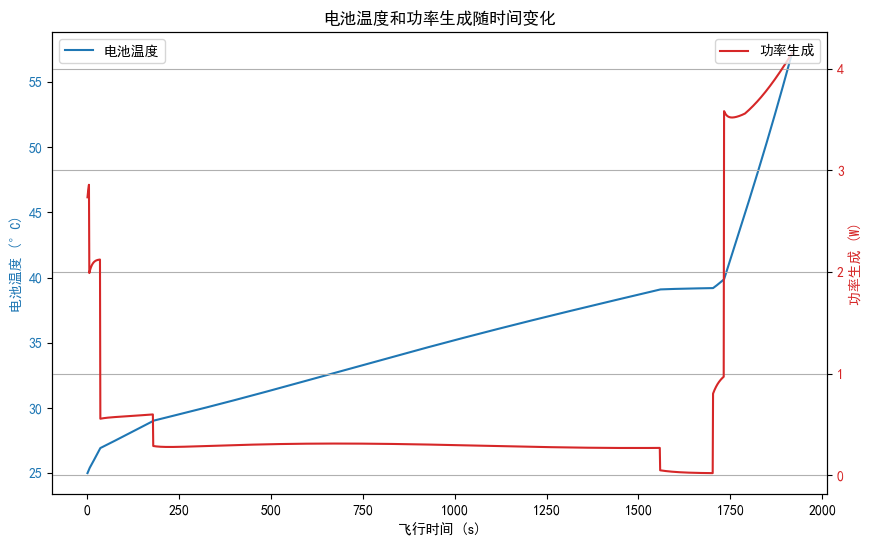

In [ ]:
# in this part, plot the battery temperature profile over time steps with and without air cooling, and the power generation profile for analysis

import matplotlib.pyplot as plt
# Add support to display Chinese characters in the plot
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use SimHei font for Chinese characters
plt.rcParams['axes.unicode_minus'] = False  # Ensure that

plt.figure(figsize=(10, 6))

time_array = np.arange(len(power_generation_data)) * dt  # create an array of time values corresponding to the time steps

# remove the last time step which contains an error
time_array = time_array[:-1]
T_bat_plot = T_bat[:-1]
power_plot = power_generation_data[:-1]  

# plot two y-axes for battery temperature and power generation
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('飞行时间 (s)')
ax1.set_ylabel('电池温度 (°C)', color=color)
ax1.plot(time_array, T_bat_plot, label='电池温度', color=color, linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')    
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('功率生成 (W)', color=color)  # we already handled the x-label with ax1
ax2.plot(time_array, power_generation_data[:-1], label='功率生成', color=color, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
plt.title('电池温度和功率生成随时间变化')
plt.grid()
plt.show()

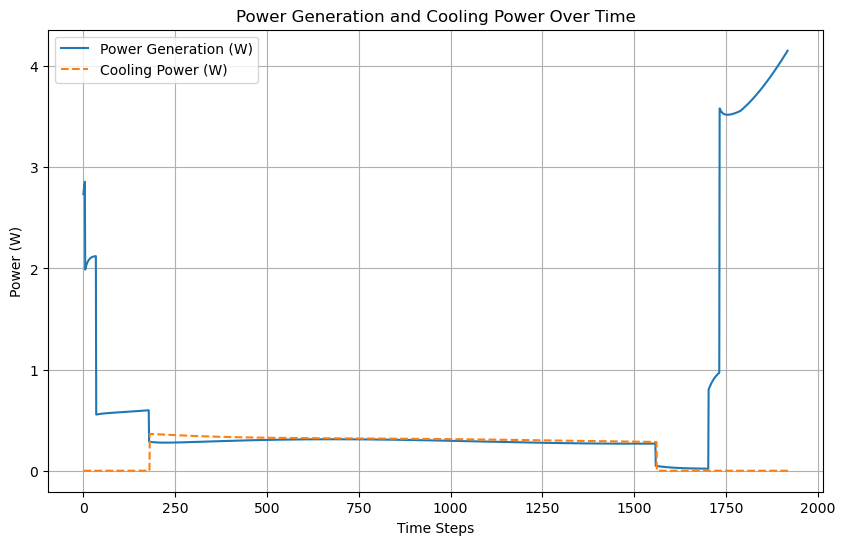

In [124]:
# plot the power generation and cooling power profiles
plt.figure(figsize=(10, 6))
plt.plot(power_generation_data, label='Power Generation (W)')
plt.plot(Q_cool_air_profile, label='Cooling Power (W)', linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('Power (W)')
plt.title('Power Generation and Cooling Power Over Time')
plt.legend()
plt.grid()
plt.show()